**Dont Forget Upvote**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("Set1")
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df=pd.read_csv('/kaggle/input/top-games-dataset/games_dataset.csv')
df.head(1)

,Game Name,Genre,Platform,Release Year,User Rating
0,Sekiro: Shadows Die Twice,Sports,Nintendo Switch,2014,9.654719


In [3]:
df.shape

(5000, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Game Name     5000 non-null   object 
 1   Genre         5000 non-null   object 
 2   Platform      5000 non-null   object 
 3   Release Year  5000 non-null   int64  
 4   User Rating   5000 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 195.4+ KB


In [5]:
df.isnull().sum()

Game Name       0
Genre           0
Platform        0
Release Year    0
User Rating     0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,Release Year,User Rating
count,5000.000000,5000.000000
mean,2011.375400,5.524913
std,6.943984,2.598429
min,2000.000000,1.005878
25%,2005.000000,3.260596
50%,2011.000000,5.574233
75%,2017.000000,7.802727
max,2023.000000,9.996196


In [8]:
genre=df['Genre'].value_counts().reset_index()
genre

,Genre,count
0,Sports,403
1,Puzzle,384
2,Racing,369
3,Simulation,368
4,Stealth,360
5,Role-playing,360
6,Horror,356
7,Strategy,353
8,Survival,353
9,Adventure,342


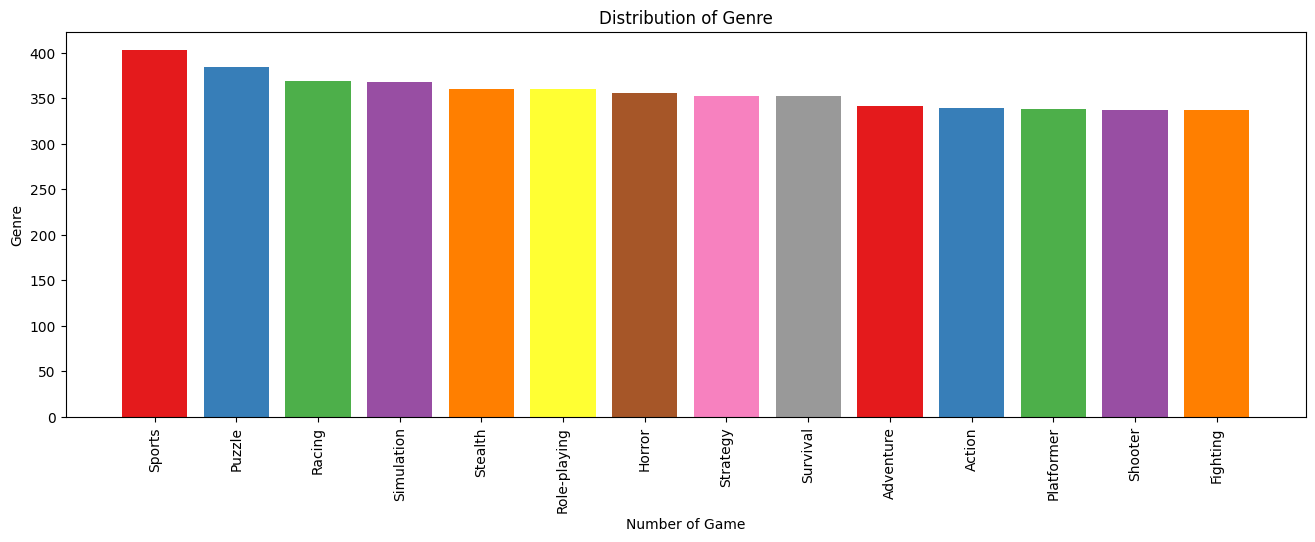

In [9]:
plt.figure(figsize=(16, 5))
plt.bar(genre['Genre'],genre['count'],color=palette)
plt.ylabel('Genre')
plt.xlabel('Number of Game')
plt.title('Distribution of Genre')
plt.xticks(rotation=90)
plt.show()

In [10]:
platform=df['Platform'].value_counts().reset_index()
platform

,Platform,count
0,PC,1056
1,Xbox,1009
2,Nintendo Switch,989
3,Mobile,986
4,PlayStation,960


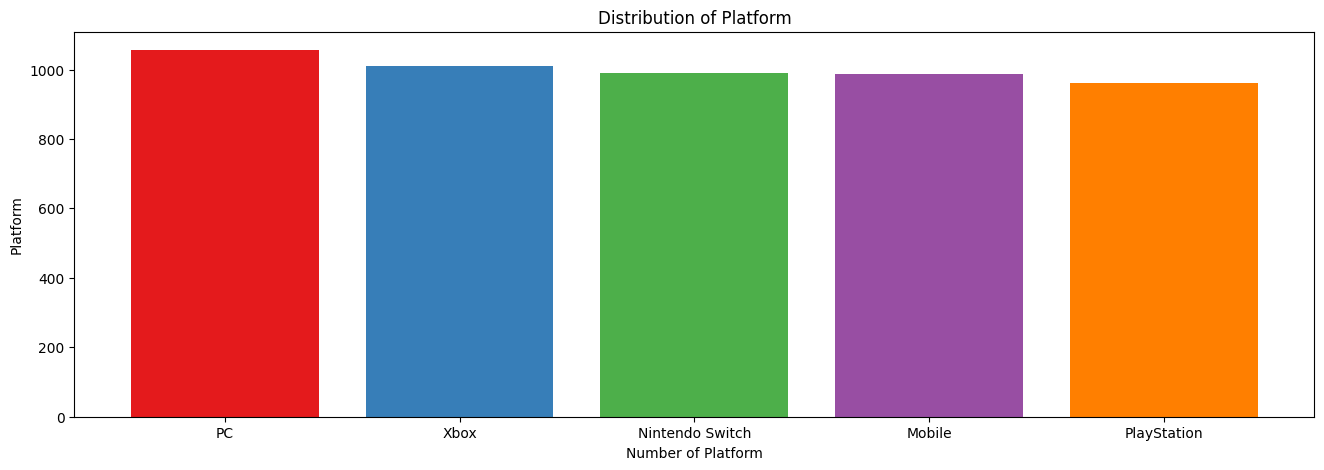

In [11]:
plt.figure(figsize=(16, 5))
plt.bar(platform['Platform'],platform['count'],color=palette)
plt.ylabel('Platform')
plt.xlabel('Number of Platform')
plt.title('Distribution of Platform')
plt.show()

In [12]:
year=df['Release Year'].value_counts().reset_index()

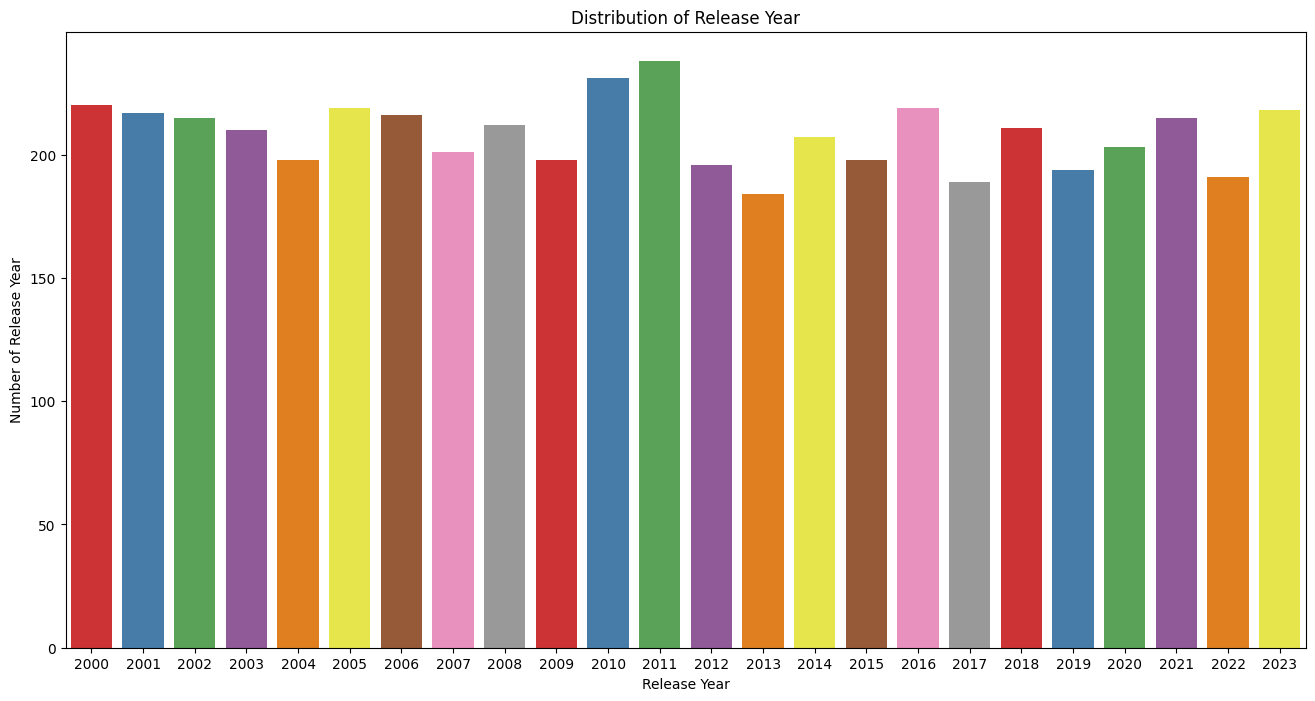

In [13]:
plt.figure(figsize=(16, 8))
sns.barplot(year, x='Release Year',y='count', palette=palette)
plt.xlabel('Release Year')
plt.ylabel('Number of Release Year')
plt.title('Distribution of Release Year')
plt.show()

In [14]:
game=df['Game Name'].value_counts().reset_index()

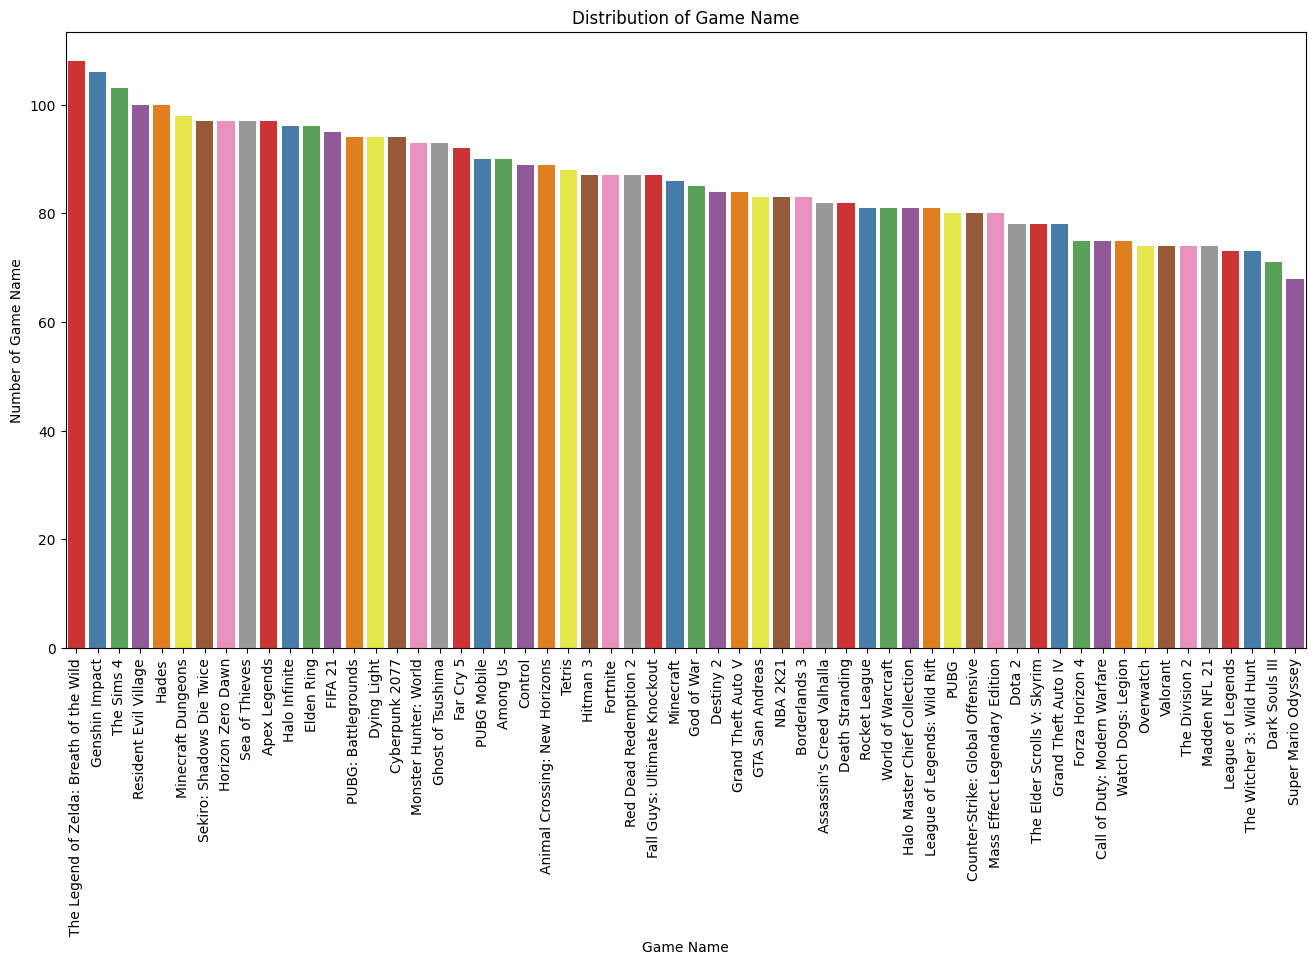

In [15]:
plt.figure(figsize=(16, 8))
sns.barplot(game, x='Game Name',y='count', palette=palette)
plt.xlabel('Game Name')
plt.ylabel('Number of Game Name')
plt.title('Distribution of Game Name')
plt.xticks(rotation=90)
plt.show()

**What is the number of each genre of game per year?**

In [16]:
genre_year=df.groupby('Genre')['Release Year'].value_counts().reset_index()
genre_year

,Genre,Release Year,count
0,Action,2021,22
1,Action,2018,21
2,Action,2014,19
3,Action,2023,18
4,Action,2000,16
...,...,...,...
331,Survival,2014,11
332,Survival,2020,11
333,Survival,2011,10
334,Survival,2021,10


/tmp/ipykernel_18/122041541.py:2: UserWarning: 
The palette list has fewer values (9) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=genre_year, x="Release Year", y="count", hue="Genre",marker='o' ,palette=palette)


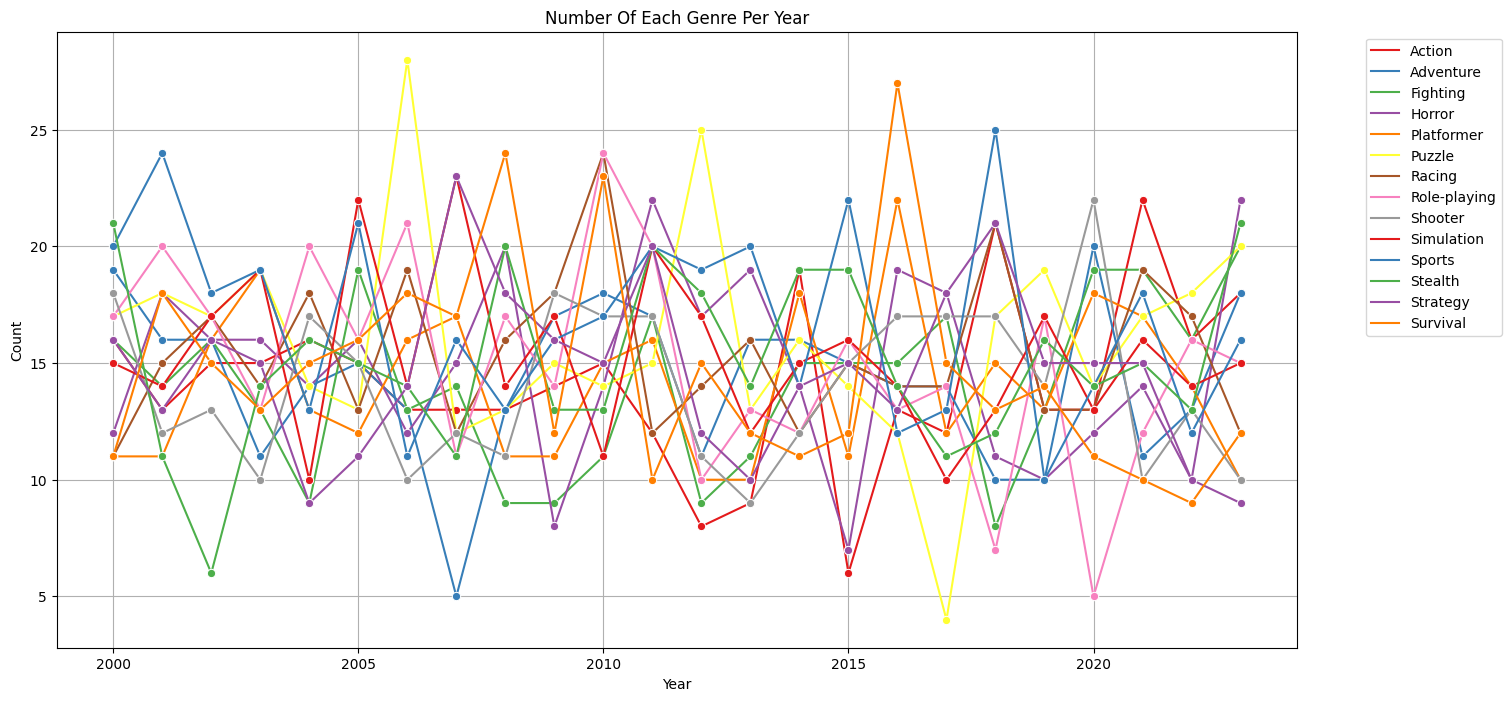

In [17]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=genre_year, x="Release Year", y="count", hue="Genre",marker='o' ,palette=palette)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number Of Each Genre Per Year')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()

**How many games does each platform have per year?**

In [18]:
platform_year=df.groupby('Platform')['Release Year'].value_counts().reset_index()
platform_year

,Platform,Release Year,count
0,Mobile,2009,50
1,Mobile,2010,50
2,Mobile,2023,49
3,Mobile,2008,48
4,Mobile,2003,47
...,...,...,...
115,Xbox,2013,36
116,Xbox,2016,36
117,Xbox,2009,33
118,Xbox,2021,32


/tmp/ipykernel_18/1055919011.py:2: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  sns.lineplot(data=platform_year, x="Release Year", y="count", hue="Platform",marker='o' ,palette=palette)


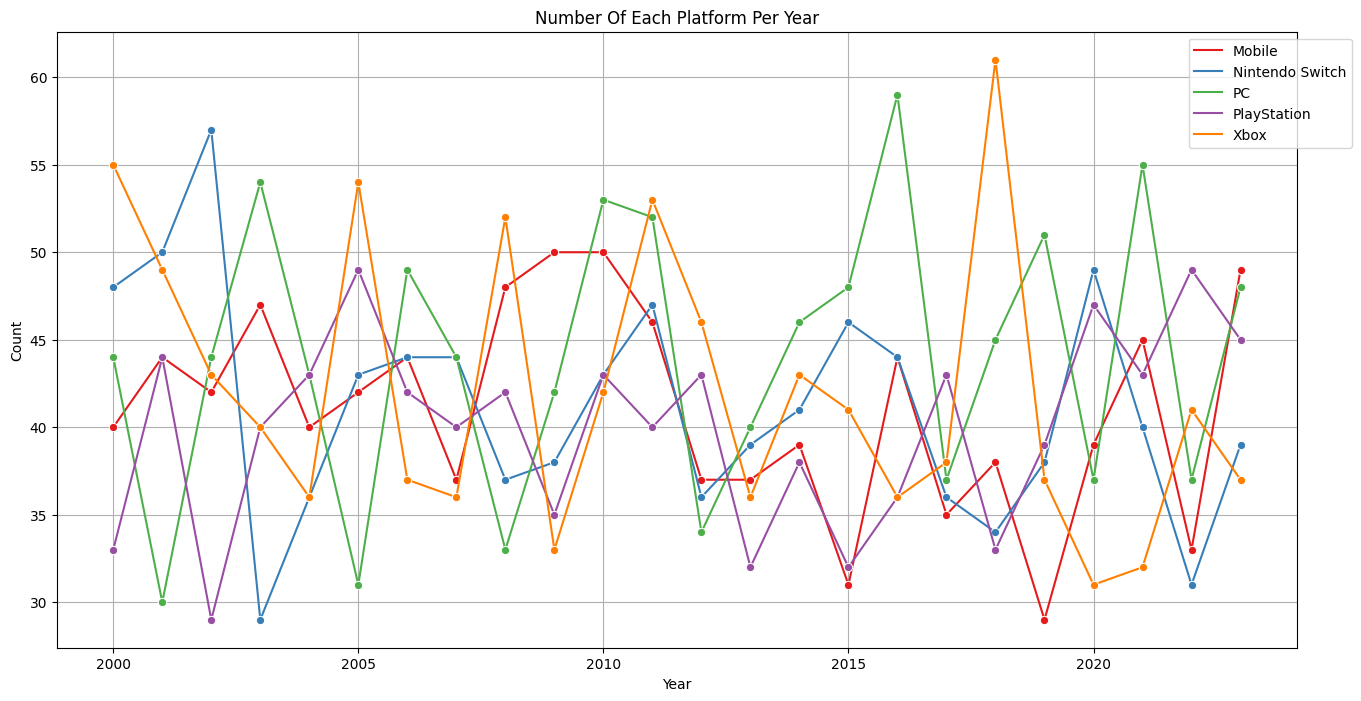

In [19]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=platform_year, x="Release Year", y="count", hue="Platform",marker='o' ,palette=palette)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number Of Each Platform Per Year')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()

**What are the highest rated games over the years?**

In [20]:
highest_rated_games = df.groupby('Release Year')['User Rating'].max().reset_index()
highest_rated_games = highest_rated_games.merge(df, on=['Release Year', 'User Rating'])
highest_rated_games

,Release Year,User Rating,Game Name,Genre,Platform
0,2000,9.993194,Control,Stealth,PlayStation
1,2001,9.927768,Ghost of Tsushima,Survival,Nintendo Switch
2,2002,9.913377,Hades,Adventure,Xbox
3,2003,9.987600,PUBG Mobile,Racing,PlayStation
4,2004,9.996196,NBA 2K21,Role-playing,Xbox
5,2005,9.920397,World of Warcraft,Horror,PlayStation
6,2006,9.948886,Halo Master Chief Collection,Sports,Nintendo Switch
7,2007,9.873948,Dying Light,Horror,Nintendo Switch
8,2008,9.823679,NBA 2K21,Shooter,Mobile
9,2009,9.814442,Fall Guys: Ultimate Knockout,Role-playing,Mobile


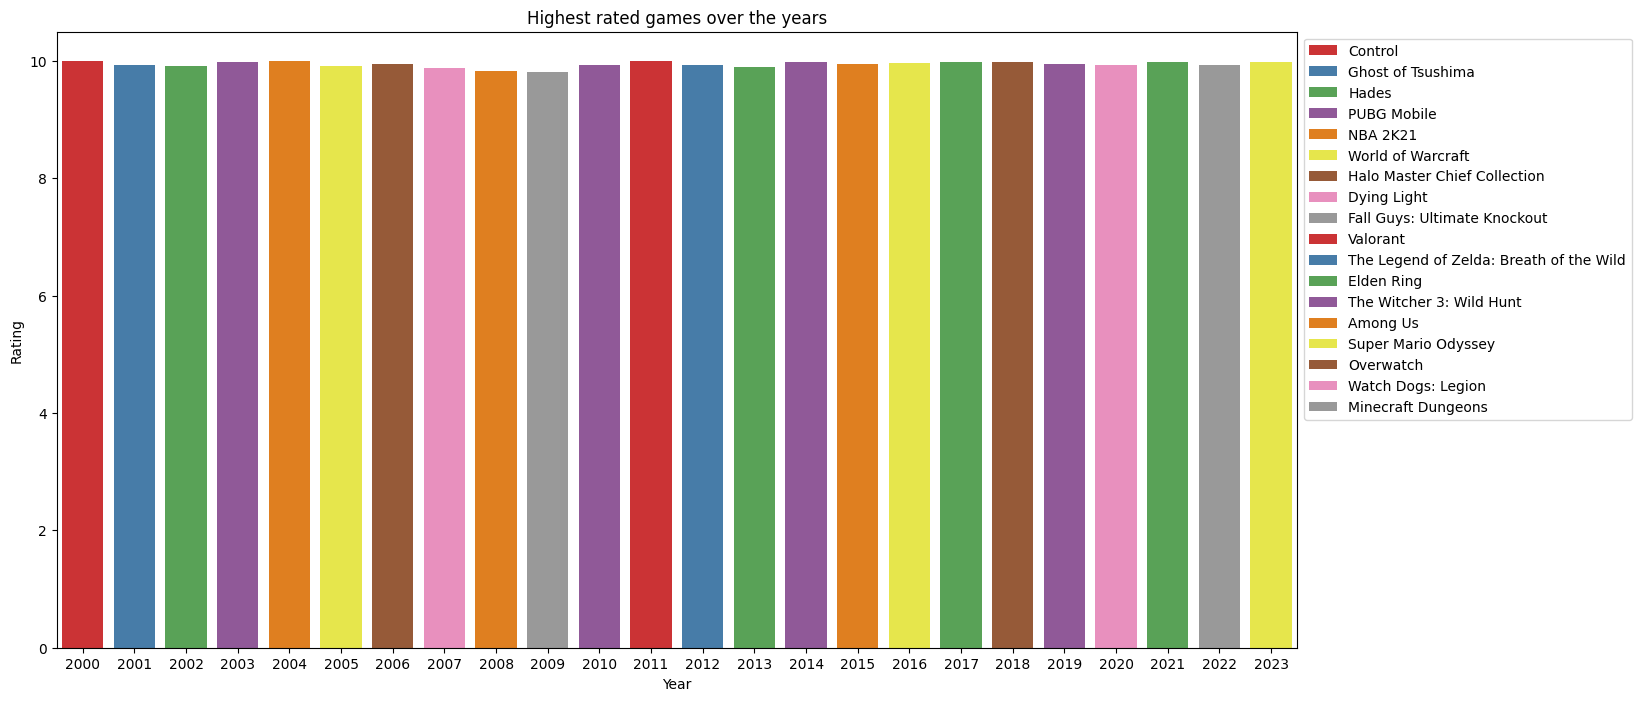

In [21]:
plt.figure(figsize=(16, 8))
sns.barplot(highest_rated_games,x='Release Year',y='User Rating',hue='Game Name',dodge=False,palette =palette)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Highest rated games over the years')
plt.ylabel('Rating')
plt.xlabel('Year')
plt.show() 

In [22]:
highest_rated_games.groupby(['Game Name','Genre'])['Game Name'].value_counts()

Game Name                                Genre       
Among Us                                 Platformer      1
Control                                  Stealth         1
Dying Light                              Horror          1
Elden Ring                               Racing          1
                                         Stealth         1
Fall Guys: Ultimate Knockout             Role-playing    1
Ghost of Tsushima                        Survival        1
Hades                                    Adventure       2
Halo Master Chief Collection             Sports          1
Minecraft Dungeons                       Horror          1
NBA 2K21                                 Role-playing    1
                                         Shooter         1
Overwatch                                Strategy        1
PUBG Mobile                              Racing          1
                                         Role-playing    1
                                         Simulation      1
Su

In [23]:
game_count=highest_rated_games['Game Name'].value_counts().reset_index()
game_count

,Game Name,count
0,PUBG Mobile,3
1,Elden Ring,2
2,Hades,2
3,NBA 2K21,2
4,World of Warcraft,2
5,Control,1
6,Watch Dogs: Legion,1
7,Overwatch,1
8,Super Mario Odyssey,1
9,Among Us,1


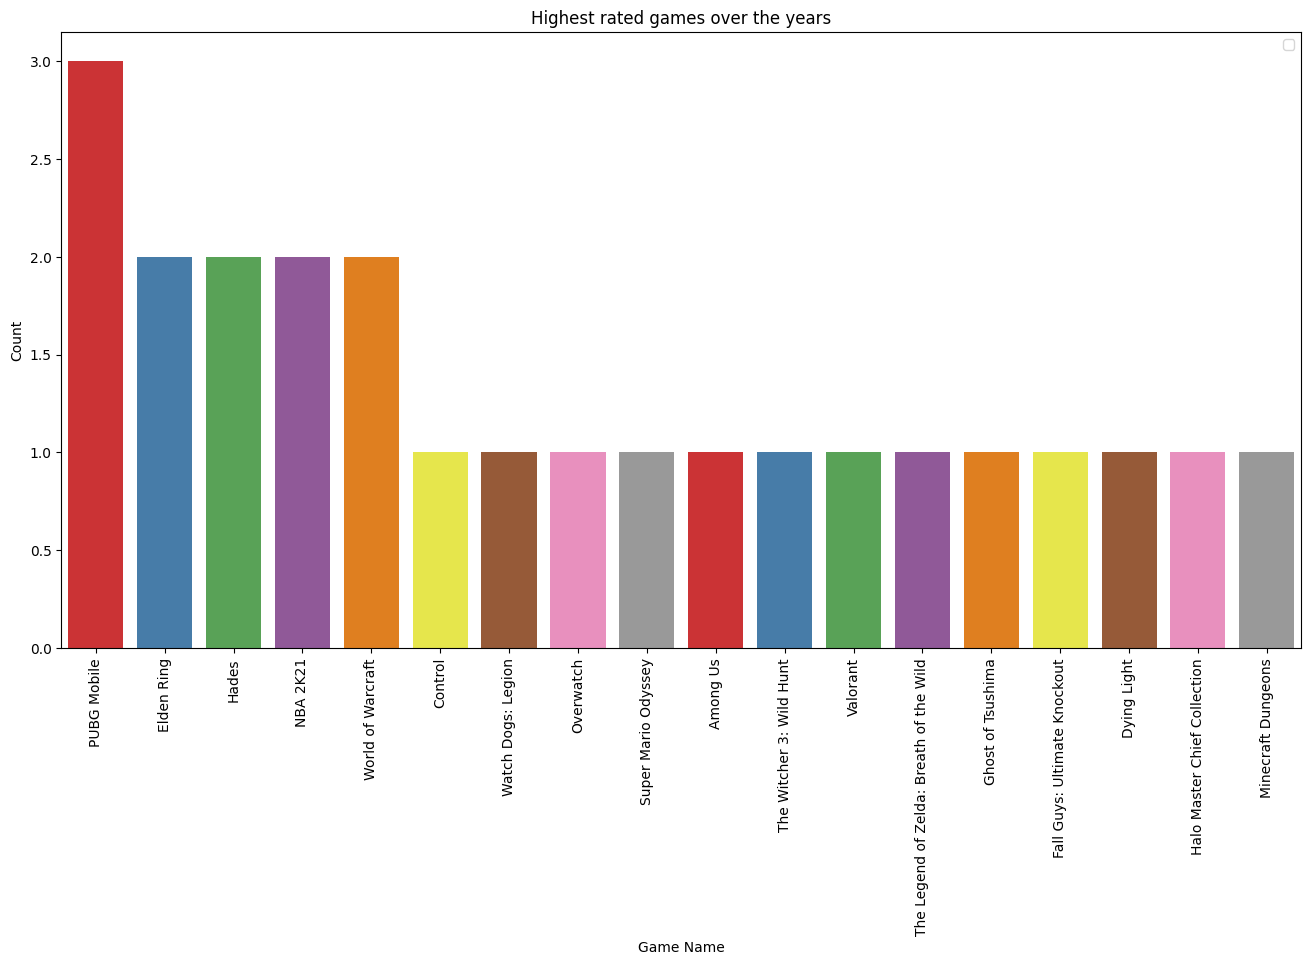

In [24]:
plt.figure(figsize=(16, 8))
sns.barplot(game_count,x='Game Name',y='count',palette =palette)
plt.title('Highest rated games over the years')
plt.ylabel('Count')
plt.xlabel('Game Name')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1,1))
plt.show() 

**What is the rating for each platform and game type?**

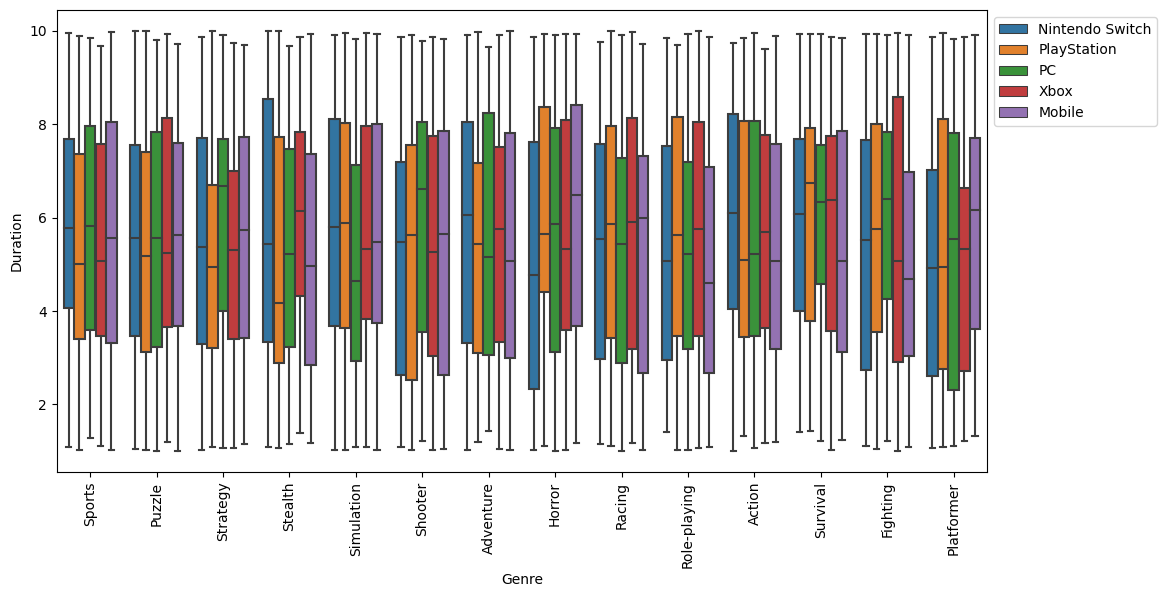

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(df, x='Genre', y='User Rating',hue='Platform')
plt.xlabel('Genre')
plt.ylabel('Duration')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

**What is the rating for each year?**

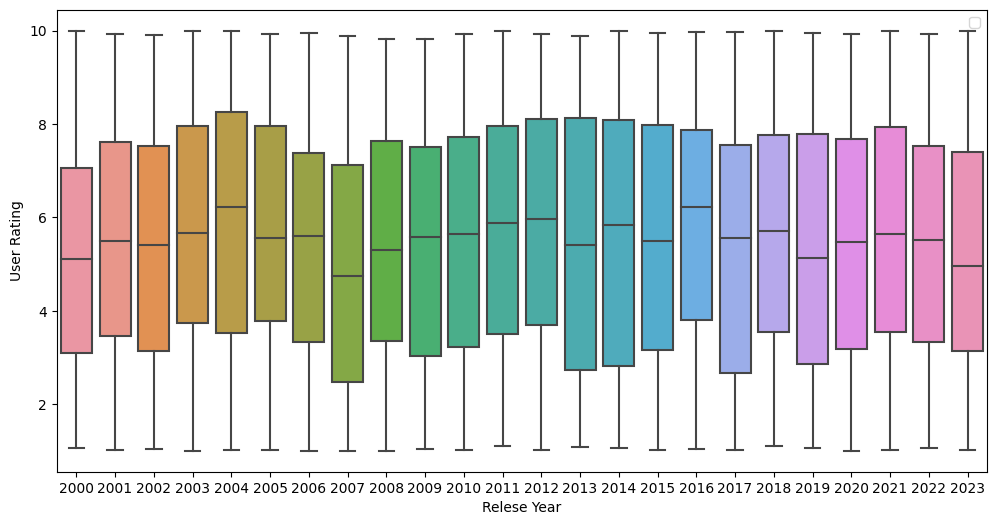

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Release Year", y="User Rating")
plt.xlabel('Relese Year')
plt.ylabel('User Rating')
#plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1,1))
plt.show() 

**How many games by genre and platform?**

In [27]:
genre_platform=df.groupby(['Genre','Platform'])['Genre'].value_counts().reset_index()

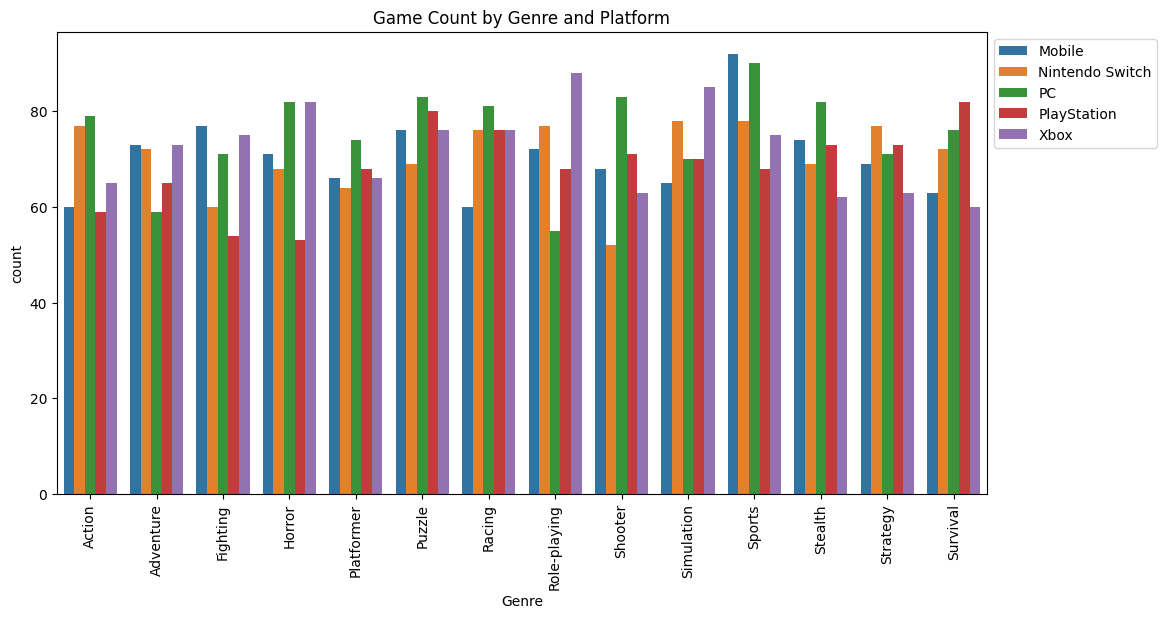

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(genre_platform,x='Genre',y='count',hue='Platform')
plt.xlabel('Genre')
plt.ylabel('count')
plt.title('Game Count by Genre and Platform')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

<Axes: xlabel='Release Year', ylabel='User Rating'>

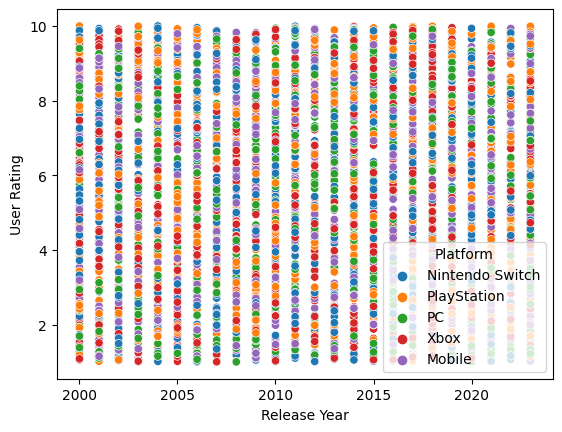

In [29]:
sns.scatterplot(data=df, x="Release Year", y="User Rating", hue="Platform")